In [1]:
import glob
import os
import librosa
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow.keras import layers, models

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

# Resize the MFCC to a fixed size function
def resize_spectrogram(spectrogram, target_size=(128, 128)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

# Preprocessing the audio files
def preprocess_audio_files(audio_files, labels, target_size=(128, 128)):
    """Convert audio files to MFCCs, resize, and normalize them."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file)
        resized_mfcc = resize_spectrogram(mfcc, target_size)
        
        # Safe normalization: Check if the max value is 0
        max_value = np.max(resized_mfcc)
        if max_value > 0:
            normalized_mfcc = resized_mfcc / max_value
        else:
            normalized_mfcc = resized_mfcc  # Leave it as is if the max is 0

        mfcc_data.append(normalized_mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label (1: spoof, 0: bonafide)

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files(valid_audio_files, valid_labels, target_size=(128, 128
                                                                            ))

# Add a channel dimension for CNN
X = np.expand_dims(X, axis=-1)


Found 45234 audio files with corresponding labels.


In [2]:
# Stratified 70:30 train-test split
def stratified_split_70_30(X, y, test_size=0.2, random_state=42):
    """Split dataset into stratified 70/30 sets."""
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    
    for train_idx, test_idx in strat_split.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
    
    # Ensure that the training set has balanced classes
    class_counts = np.bincount(y_train)
    min_class_count = min(class_counts)
    spoof_indices = np.where(y_train == 1)[0][:min_class_count]
    bonafide_indices = np.where(y_train == 0)[0][:min_class_count]
    balanced_train_indices = np.concatenate([spoof_indices, bonafide_indices])
    X_train_balanced, y_train_balanced = X_train[balanced_train_indices], y_train[balanced_train_indices]

    return X_train_balanced, X_test, y_train_balanced, y_test

# Perform the stratified 80/30 split
X_train, X_test, y_train, y_test = stratified_split_70_30(X, y, test_size=0.2, random_state=42)

# Print the distribution of classes to verify stratification
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Test set distribution: {np.bincount(y_test)}")

Training set distribution: [18093 18093]
Test set distribution: [4524 4523]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,185 (6.21 MB)

 Trainable params: 1,629,185 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 106s 358ms/step - accuracy: 0.7129 - loss: 0.6695 - val_accuracy: 0.7834 - val_loss: 0.4563
Epoch 2/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 97s 341ms/step - accuracy: 0.7857 - loss: 0.4565 - val_accuracy: 0.8045 - val_loss: 0.4161
Epoch 3/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 92s 326ms/step - accuracy: 0.7977 - loss: 0.4257 - val_accuracy: 0.8250 - val_loss: 0.3679
Epoch 4/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 92s 324ms/step - accuracy: 0.8192 - loss: 0.3757 - val_accuracy: 0.8447 - val_loss: 0.3323
Epoch 5/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 96s 339ms/step - accuracy: 0.8401 - loss: 0.3334 - val_accuracy: 0.8701 - val_loss: 0.2932
Epoch 6/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 99s 351ms/step - accuracy: 0.8584 - loss: 0.3015 - val_accuracy: 0.8848 - val_loss: 0.2546
Epoch 7/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 92s 327ms/step - accuracy: 0.8741 - loss: 0.2657 - val_accuracy: 0.9000 - val_loss: 0.2261
Epoch 8/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 92s 326ms/step - accuracy: 0.8869 

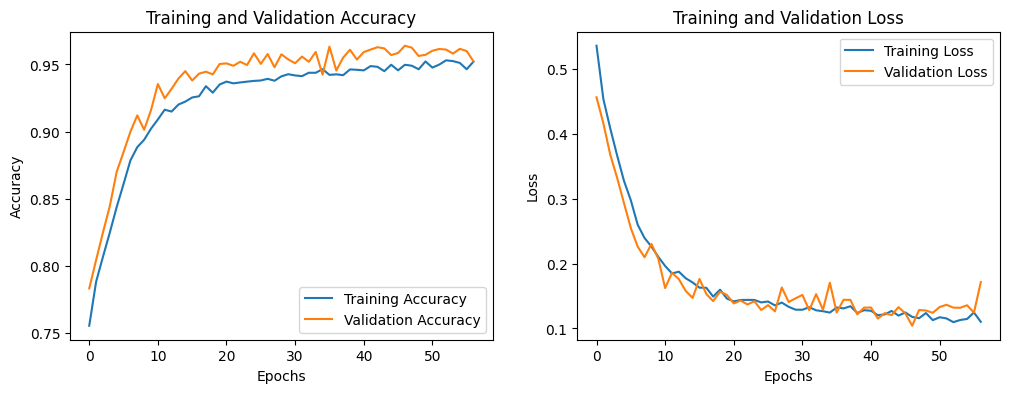

In [4]:
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the CNN architecture
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer
    model.add(layers.Conv2D(16, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 2nd Convolutional Layer
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 3rd Convolutional Layer
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.4))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

# Create the model
input_shape = (128, 128, 1)  # Shape of input (height, width, channels)
model = build_cnn(input_shape)

# Set a custom learning rate and weight decay for AdamW
learning_rate = 0.01
weight_decay = 0.01
optimizer = AdamW(learning_rate=learning_rate, weight_decay=weight_decay)

# Compile the model with AdamW optimizer
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


283/283 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step


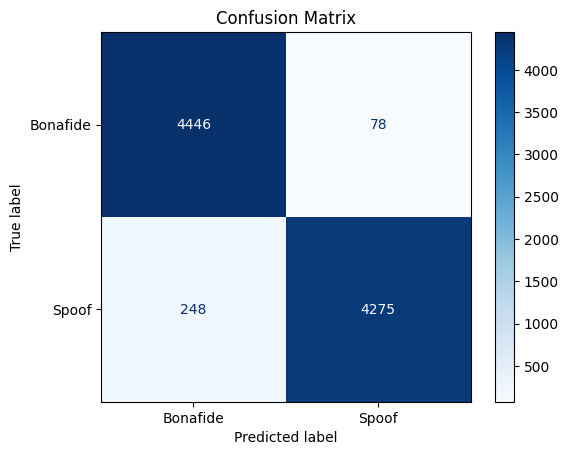

Precision: 0.98
Recall: 0.95
F1 Score: 0.96


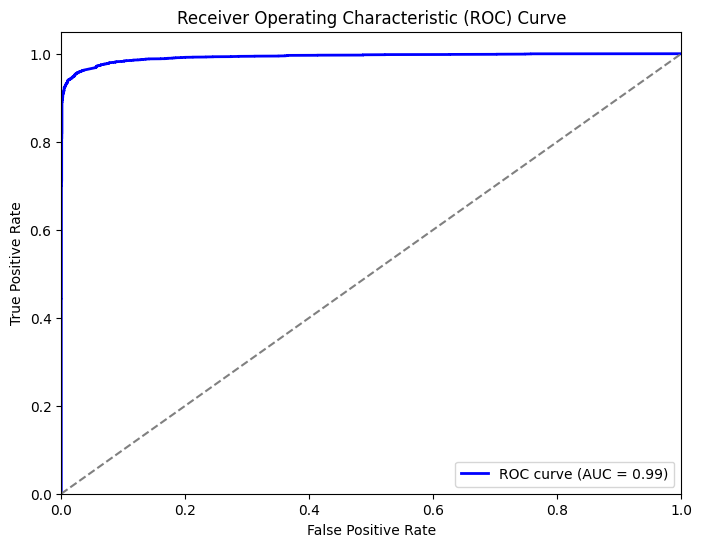

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

# Predict the probability scores on the test set
y_pred_prob = model.predict(X_test).ravel()  # Flatten the array for binary classification
y_pred_class = (y_pred_prob >= 0.5).astype(int)   # Convert probabilities to binary classes (0 or 1)

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Bonafide', 'Spoof'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Compute precision, recall, and F1 score
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

# Print precision, recall, and F1 score
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Compute the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,185 (6.21 MB)

 Trainable params: 1,629,185 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 103s 435ms/step - accuracy: 0.7092 - loss: 0.7130 - val_accuracy: 0.5432 - val_loss: 0.9659
Epoch 2/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 88s 388ms/step - accuracy: 0.8129 - loss: 0.4557 - val_accuracy: 0.6529 - val_loss: 0.5497
Epoch 3/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 95s 418ms/step - accuracy: 0.8202 - loss: 0.4356 - val_accuracy: 0.6832 - val_loss: 0.5059
Epoch 4/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 114s 500ms/step - accuracy: 0.8295 - loss: 0.4001 - val_accuracy: 0.8051 - val_loss: 0.3345
Epoch 5/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 107s 472ms/step - accuracy: 0.8351 - loss: 0.3822 - val_accuracy: 0.6803 - val_loss: 0.7005
Epoch 6/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 84s 371ms/step - accuracy: 0.8527 - loss: 0.3495 - val_accuracy: 0.8216 - val_loss: 0.3327
Epoch 7/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 93s 410ms/step - accuracy: 0.8780 - loss: 0.3005 - val_accuracy: 0.8361 - val_loss: 0.3416
Epoch 8/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 90s 395ms/step - accuracy: 0.883

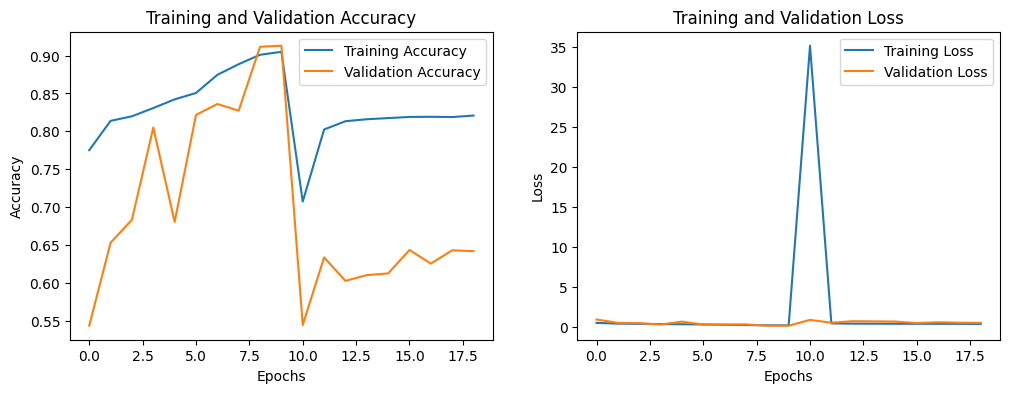

In [7]:
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the CNN architecture
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(16, kernel_size=(3, 3), input_shape=input_shape))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 2nd Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(32, kernel_size=(3, 3)))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 3rd Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(64, kernel_size=(3, 3)))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.Dropout(0.4))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

# Create the model
input_shape = (128, 128, 1)  # Shape of input (height, width, channels)
model = build_cnn(input_shape)

# Set a custom learning rate and weight decay for AdamW
learning_rate = 0.01
weight_decay = 0.1
optimizer = AdamW(learning_rate=learning_rate, weight_decay=weight_decay)

# Compile the model with AdamW optimizer
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


283/283 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step


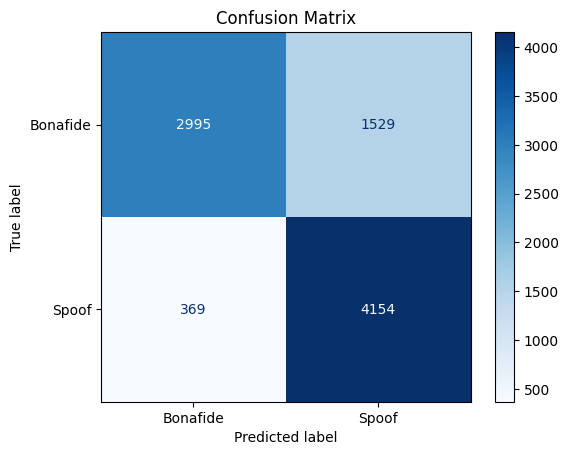

Precision: 0.73
Recall: 0.92
F1 Score: 0.81


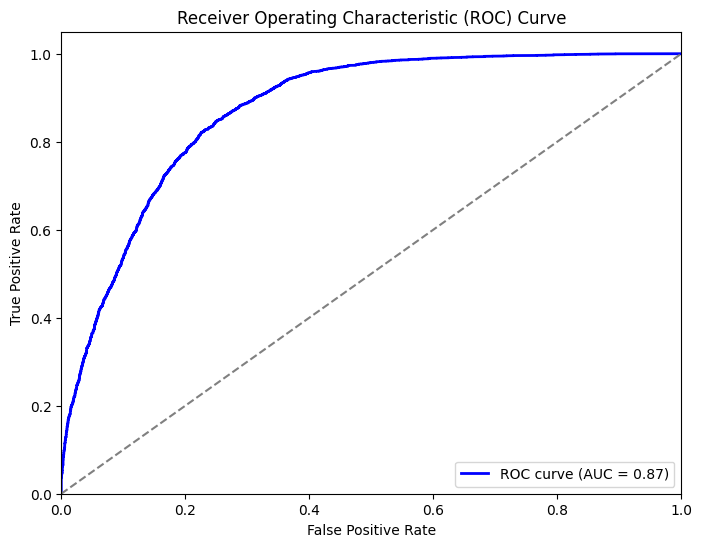

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

# Predict the probability scores on the test set
y_pred_prob = model.predict(X_test).ravel()  # Flatten the array for binary classification
y_pred_class = (y_pred_prob >= 0.5).astype(int)   # Convert probabilities to binary classes (0 or 1)

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Bonafide', 'Spoof'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Compute precision, recall, and F1 score
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

# Print precision, recall, and F1 score
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Compute the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,185 (6.21 MB)

 Trainable params: 1,629,185 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 106s 451ms/step - accuracy: 0.6697 - loss: 0.8451 - val_accuracy: 0.5993 - val_loss: 0.7261
Epoch 2/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 87s 382ms/step - accuracy: 0.8067 - loss: 0.4778 - val_accuracy: 0.6044 - val_loss: 0.7323
Epoch 3/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 85s 376ms/step - accuracy: 0.8092 - loss: 0.4576 - val_accuracy: 0.6534 - val_loss: 0.6481
Epoch 4/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 96s 425ms/step - accuracy: 0.8173 - loss: 0.4262 - val_accuracy: 0.6491 - val_loss: 0.6455
Epoch 5/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 98s 434ms/step - accuracy: 0.8294 - loss: 0.3880 - val_accuracy: 0.6898 - val_loss: 0.5252
Epoch 6/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 97s 429ms/step - accuracy: 0.8449 - loss: 0.3528 - val_accuracy: 0.6511 - val_loss: 0.6165
Epoch 7/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 100s 440ms/step - accuracy: 0.8573 - loss: 0.3288 - val_accuracy: 0.7769 - val_loss: 0.4084
Epoch 8/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 91s 399ms/step - accuracy: 0.8556

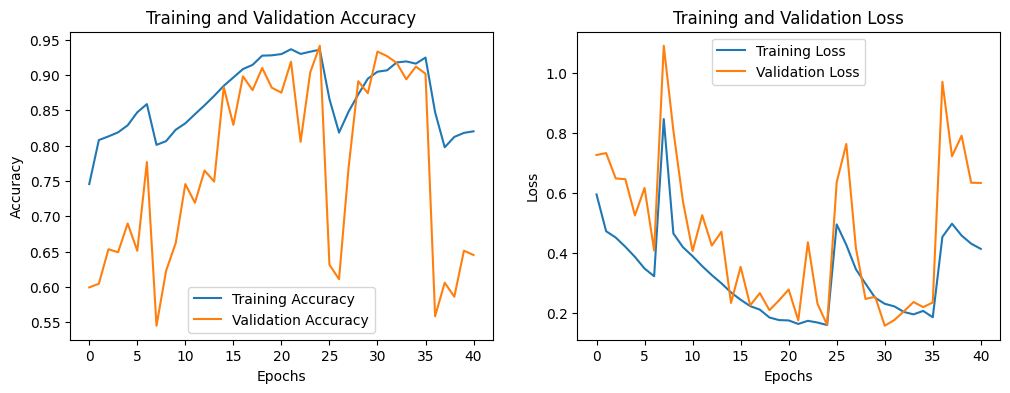

283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step


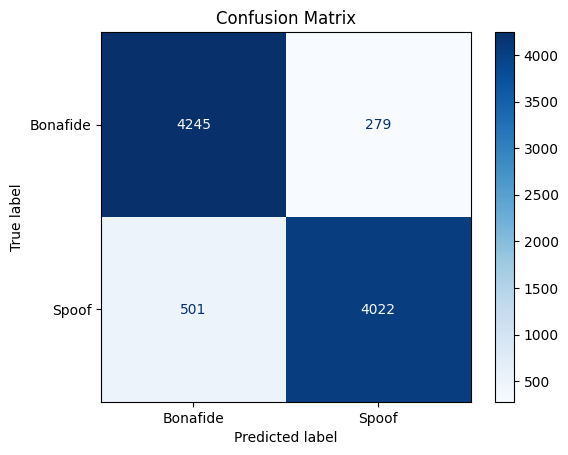

Precision: 0.94
Recall: 0.89
F1 Score: 0.91


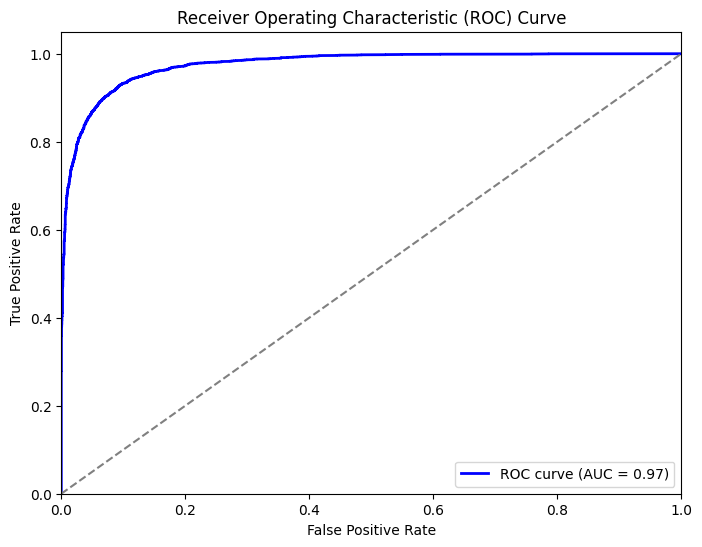

In [11]:
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the CNN architecture
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(16, kernel_size=(3, 3), input_shape=input_shape))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 2nd Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(32, kernel_size=(3, 3)))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 3rd Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(64, kernel_size=(3, 3)))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.Dropout(0.4))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

# Create the model
input_shape = (128, 128, 1)  # Shape of input (height, width, channels)
model = build_cnn(input_shape)

# Set a custom learning rate and weight decay for AdamW
learning_rate = 0.01
weight_decay = 0.1
optimizer = AdamW(learning_rate=learning_rate, weight_decay=weight_decay)

# Compile the model with AdamW optimizer
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

# Predict the probability scores on the test set
y_pred_prob = model.predict(X_test).ravel()  # Flatten the array for binary classification
y_pred_class = (y_pred_prob >= 0.5).astype(int)   # Convert probabilities to binary classes (0 or 1)

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Bonafide', 'Spoof'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Compute precision, recall, and F1 score
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

# Print precision, recall, and F1 score
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Compute the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [16]:
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the CNN architecture
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(16, kernel_size=(3, 3), input_shape=input_shape))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 2nd Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(32, kernel_size=(3, 3)))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 3rd Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(64, kernel_size=(3, 3)))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.Dropout(0.4))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

# Create the model
input_shape = (128, 128, 1)  # Shape of input (height, width, channels)
model = build_cnn(input_shape)

# Set a custom learning rate and weight decay for AdamW
learning_rate = 0.01
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with AdamW optimizer
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_split=0.2 , callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

# Predict the probability scores on the test set
y_pred_prob = model.predict(X_test).ravel()  # Flatten the array for binary classification
y_pred_class = (y_pred_prob >= 0.5).astype(int)   # Convert probabilities to binary classes (0 or 1)

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Bonafide', 'Spoof'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Compute precision, recall, and F1 score
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

# Print precision, recall, and F1 score
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Compute the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_32 (LeakyReLU)      │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_33 (LeakyReLU)      │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_34 (LeakyReLU)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_35 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,185 (6.21 MB)

 Trainable params: 1,629,185 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 108s 459ms/step - accuracy: 0.7151 - loss: 0.9313 - val_accuracy: 0.6141 - val_loss: 0.7335
Epoch 2/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 80s 354ms/step - accuracy: 0.8050 - loss: 0.4836 - val_accuracy: 0.6217 - val_loss: 0.6875
Epoch 3/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 83s 367ms/step - accuracy: 0.8123 - loss: 0.4514 - val_accuracy: 0.5725 - val_loss: 0.9152
Epoch 4/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 80s 351ms/step - accuracy: 0.8176 - loss: 0.4285 - val_accuracy: 0.7089 - val_loss: 0.4655
Epoch 5/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 84s 371ms/step - accuracy: 0.8319 - loss: 0.3886 - val_accuracy: 0.6158 - val_loss: 0.8834
Epoch 6/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 82s 363ms/step - accuracy: 0.8461 - loss: 0.3461 - val_accuracy: 0.7360 - val_loss: 0.4722
Epoch 7/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 88s 388ms/step - accuracy: 0.8671 - loss: 0.3060 - val_accuracy: 0.7897 - val_loss: 0.4278
Epoch 8/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 96s 421ms/step - accuracy: 0.8914 

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the CNN architecture
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(16, kernel_size=(3, 3), input_shape=input_shape))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 2nd Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(32, kernel_size=(3, 3)))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 3rd Convolutional Layer with LeakyReLU
    model.add(layers.Conv2D(64, kernel_size=(3, 3)))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.Dropout(0.4))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

# Create the model
input_shape = (128, 128, 1)  # Shape of input (height, width, channels)
model = build_cnn(input_shape)

# Set a custom learning rate and weight decay for AdamW
learning_rate = 0.01
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with AdamW optimizer
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_, callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

# Predict the probability scores on the test set
y_pred_prob = model.predict(X_test).ravel()  # Flatten the array for binary classification
y_pred_class = (y_pred_prob >= 0.5).astype(int)   # Convert probabilities to binary classes (0 or 1)

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Bonafide', 'Spoof'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Compute precision, recall, and F1 score
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

# Print precision, recall, and F1 score
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Compute the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()